In [3]:
import pandas as pd
import numpy as np
df_final = pd.read_csv(
    "data/df_final_clean.csv",
    encoding="utf-8-sig"
)

df_final.head()

,Zone,ISO3,Population,disponibilite_volaille,PIB_habitant,Stabilité_Politique,inflation,index_ouverture,index_log,Balance_commerciale,distance_france_km,Population_log,PIB_habitant_log,Stabilité_Politique_log,inflation_log,distance_france_log,index_ouverture_log,disponibilite_volaille_log
0,Afghanistan,AFG,35688941,27637.84,525.469771,-1.442187,4.975952,NaN,1.790851,-26227.0,5596.702065,17.390351,6.266194,NaN,1.787743,8.630111,NaN,10.226977
1,Africa (UN),UN_AFR,1282902113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.972391,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,ALB,2898245,14414.11,5006.360130,0.256049,1.986661,76.787382,2.460908,-3266.0,1603.327048,14.879616,8.518664,0.227971,1.094156,7.380460,4.353979,9.576032
3,Algeria,DZA,41689302,400005.80,4554.667540,-0.523158,5.591116,49.820816,2.209783,-19051.0,1336.701248,17.545755,8.424127,-0.740570,1.885723,7.198708,3.928306,12.899237
4,American Samoa,ASM,51605,NaN,11863.683945,0.766425,NaN,161.437908,NaN,NaN,NaN,10.851393,9.381322,0.568958,NaN,NaN,5.090296,NaN


In [4]:
df_final['Population_log'] = np.log1p(df_final['Population'])
df_final['PIB_habitant_log'] = np.log1p(df_final['PIB_habitant'])
df_final['Stabilité_Politique_log'] = np.log1p(df_final["Stabilité_Politique"])
df_final['inflation_log'] = np.log1p(df_final["inflation"])
df_final["distance_france_log"] = np.log1p(df_final["distance_france_km"])
df_final["index_ouverture_log"] = np.log1p(df_final["index_ouverture"])
df_final["disponibilite_volaille_log"] = np.log1p(df_final["disponibilite_volaille"])



from sklearn.preprocessing import StandardScaler

variables_acp = [
    "Population_log",
    "PIB_habitant_log",
    "Stabilité_Politique",
    "inflation",
    "index_ouverture",
    "index_log",
    "Balance_commerciale",
    "distance_france_log",
    "disponibilite_volaille"
]

X = df_final[variables_acp].copy()

X_scaled = StandardScaler().fit_transform(X)

X = X.apply(pd.to_numeric, errors="coerce")

# Remplacer les valeurs infinies par NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Afficher les valeurs manquantes
print("Valeurs manquantes avant nettoyage :")
print(X.isna().sum().sort_values(ascending=False))


X = X.dropna()





c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Valeurs manquantes avant nettoyage :
index_log                 106
index_ouverture            86
inflation                  85
Balance_commerciale        82
Stabilité_Politique        66
PIB_habitant_log           65
disponibilite_volaille     51
distance_france_log        50
Population_log              0
dtype: int64


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [6]:
from sklearn.decomposition import PCA

acp = PCA()

X_acp = acp.fit_transform(X_scaled)

In [7]:
# ACP avec 4 composantes
acp = PCA(n_components=4)

X_acp = acp.fit_transform(X_scaled)

# Coordonnées des individus
acp_df = pd.DataFrame(
    X_acp,
    columns=["D1", "D2", "D3", "D4"]
)
acp_df["Zone"] = df_final.loc[X.index, "Zone"].values

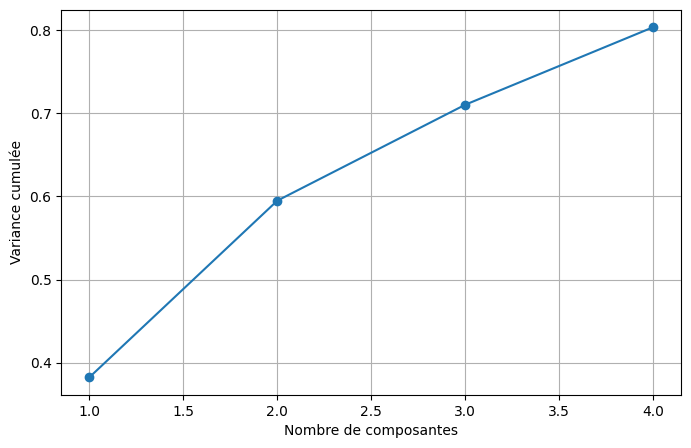

ACP1: 0.382
ACP2: 0.213
ACP3: 0.115
ACP4: 0.093


In [8]:
import matplotlib.pyplot as plt

explained_var = acp.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(explained_var)+1),
    np.cumsum(explained_var),
    marker='o'
)
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée')
plt.grid()
plt.show()

for i, v in enumerate(explained_var):
    print(f"ACP{i+1}: {v:.3f}")


In [9]:
loadings = pd.DataFrame(
    acp.components_.T,
    columns=["D1", "D2", "D3", "D4"],
    index=X.columns
)

print(loadings)

                              D1        D2        D3        D4
Population_log         -0.148723  0.610839  0.019072  0.192869
PIB_habitant_log        0.491189  0.078604 -0.081939  0.051661
Stabilité_Politique     0.488120  0.135089 -0.047088  0.103105
inflation              -0.271341 -0.007722  0.243391  0.838700
index_ouverture         0.345225 -0.342741 -0.151205  0.202340
index_log               0.449476  0.313607 -0.021953  0.106708
Balance_commerciale     0.096355  0.167819  0.854970 -0.317402
distance_france_log    -0.306972  0.180584 -0.365183 -0.303890
disponibilite_volaille  0.001453  0.570784 -0.209259  0.025763


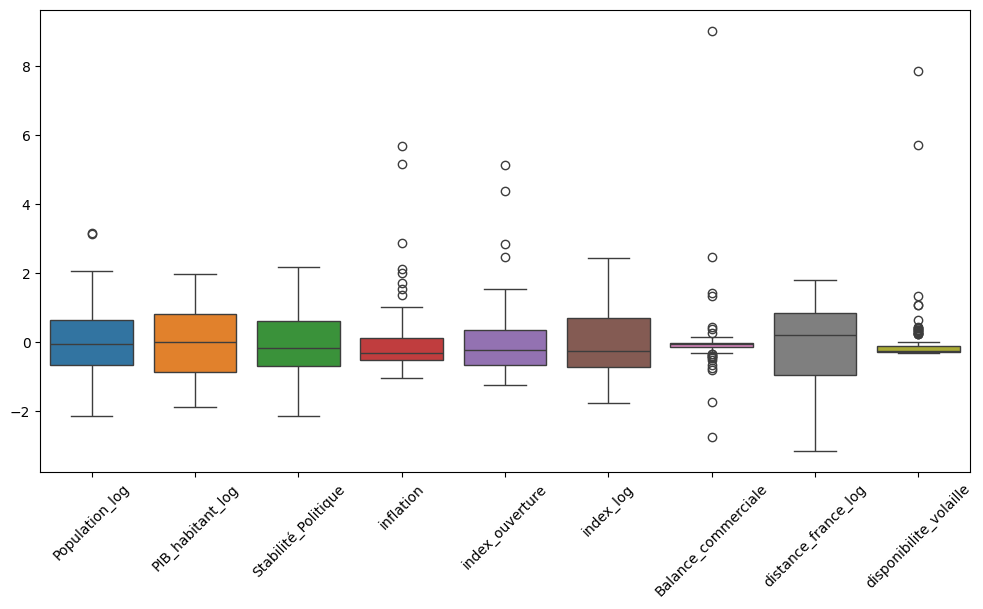

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

plt.figure(figsize=(12,6))
sns.boxplot(data=X_scaled_df)
plt.xticks(rotation=45)
plt.show()

In [11]:

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print(X_scaled.describe())


       Population_log  PIB_habitant_log  Stabilité_Politique     inflation  \
count    1.060000e+02      1.060000e+02         1.060000e+02  1.060000e+02   
mean     2.602740e-16      1.229101e-15        -2.094760e-17 -1.633913e-16   
std      1.004751e+00      1.004751e+00         1.004751e+00  1.004751e+00   
min     -2.144163e+00     -1.868784e+00        -2.150162e+00 -1.055349e+00   
25%     -6.799517e-01     -8.582119e-01        -7.043594e-01 -5.193087e-01   
50%     -7.073977e-02     -7.667488e-03        -1.700147e-01 -3.290897e-01   
75%      6.309253e-01      8.063081e-01         6.144694e-01  1.056454e-01   
max      3.150572e+00      1.976624e+00         2.171442e+00  5.662544e+00   

       index_ouverture     index_log  Balance_commerciale  \
count     1.060000e+02  1.060000e+02         1.060000e+02   
mean     -2.251867e-16  6.116700e-16         4.516827e-18   
std       1.004751e+00  1.004751e+00         1.004751e+00   
min      -1.245620e+00 -1.759878e+00        -2.737306

                              D1        D2        D3        D4
Population_log         -0.148723  0.610839  0.019072  0.192869
PIB_habitant_log        0.491189  0.078604 -0.081939  0.051661
Stabilité_Politique     0.488120  0.135089 -0.047088  0.103105
inflation              -0.271341 -0.007722  0.243391  0.838700
index_ouverture         0.345225 -0.342741 -0.151205  0.202340
index_log               0.449476  0.313607 -0.021953  0.106708
Balance_commerciale     0.096355  0.167819  0.854970 -0.317402
distance_france_log    -0.306972  0.180584 -0.365183 -0.303890
disponibilite_volaille  0.001453  0.570784 -0.209259  0.025763


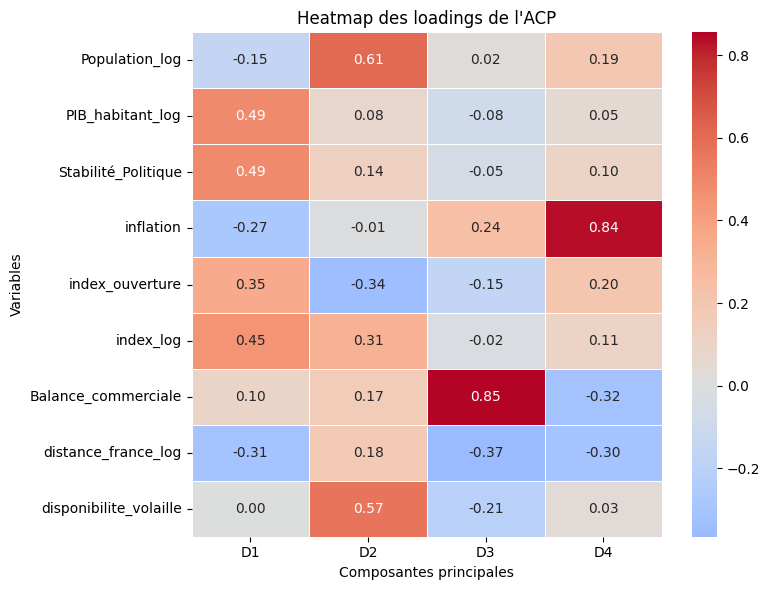

In [12]:
loadings = pd.DataFrame(
    acp.components_.T,
    columns=['D1','D2','D3','D4'],
    index=X.columns
)

print(loadings)

plt.figure(figsize=(8,6))

sns.heatmap(
    loadings,
    annot=True,          # affiche les valeurs
    cmap="coolwarm",     # bleu = négatif, rouge = positif
    center=0,            # centre sur 0
    fmt=".2f",           # 2 décimales
    linewidths=0.5
)

plt.title("Heatmap des loadings de l'ACP")
plt.xlabel("Composantes principales")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


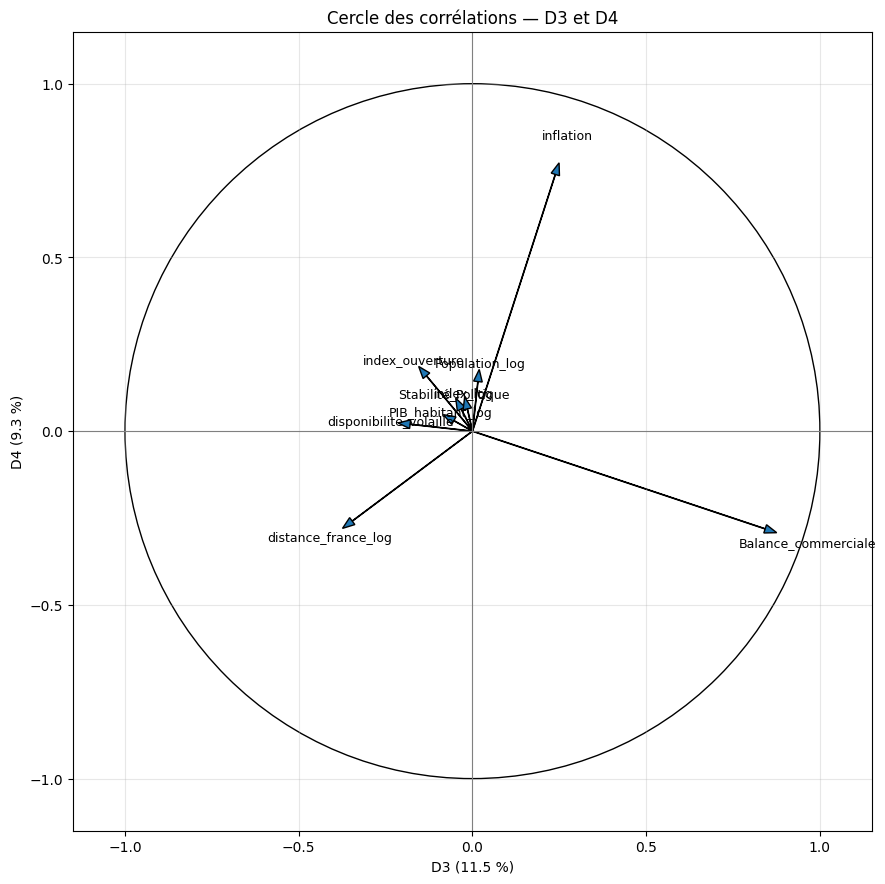

In [13]:
corr_variables = (
    acp.components_.T
    * np.sqrt(acp.explained_variance_)
)

fig, ax = plt.subplots(figsize=(9, 9))

# Cercle unité
cercle = plt.Circle(
    (0, 0),
    1,
    fill=False,
    edgecolor="black"
)
ax.add_patch(cercle)

# Axes horizontaux et verticaux
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)

# Flèches et noms des variables
for i, variable in enumerate(X.columns):
    x = corr_variables[i, 2]  # D1
    y = corr_variables[i, 3]  # D2

    ax.arrow(
        0,
        0,
        x,
        y,
        head_width=0.025,
        head_length=0.035,
        length_includes_head=True
    )

    ax.text(
        x * 1.10,
        y * 1.10,
        variable,
        fontsize=9,
        ha="center",
        va="center"
    )

# Limites identiques pour avoir un vrai cercle
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_aspect("equal")

# Variance expliquée dans les titres des axes
variance = acp.explained_variance_ratio_ * 100

ax.set_xlabel(f"D3 ({variance[2]:.1f} %)")
ax.set_ylabel(f"D4 ({variance[3]:.1f} %)")
ax.set_title("Cercle des corrélations — D3 et D4")

ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_acp)

# Ajouter les clusters au DataFrame ACP
acp_df["Cluster"] = clusters


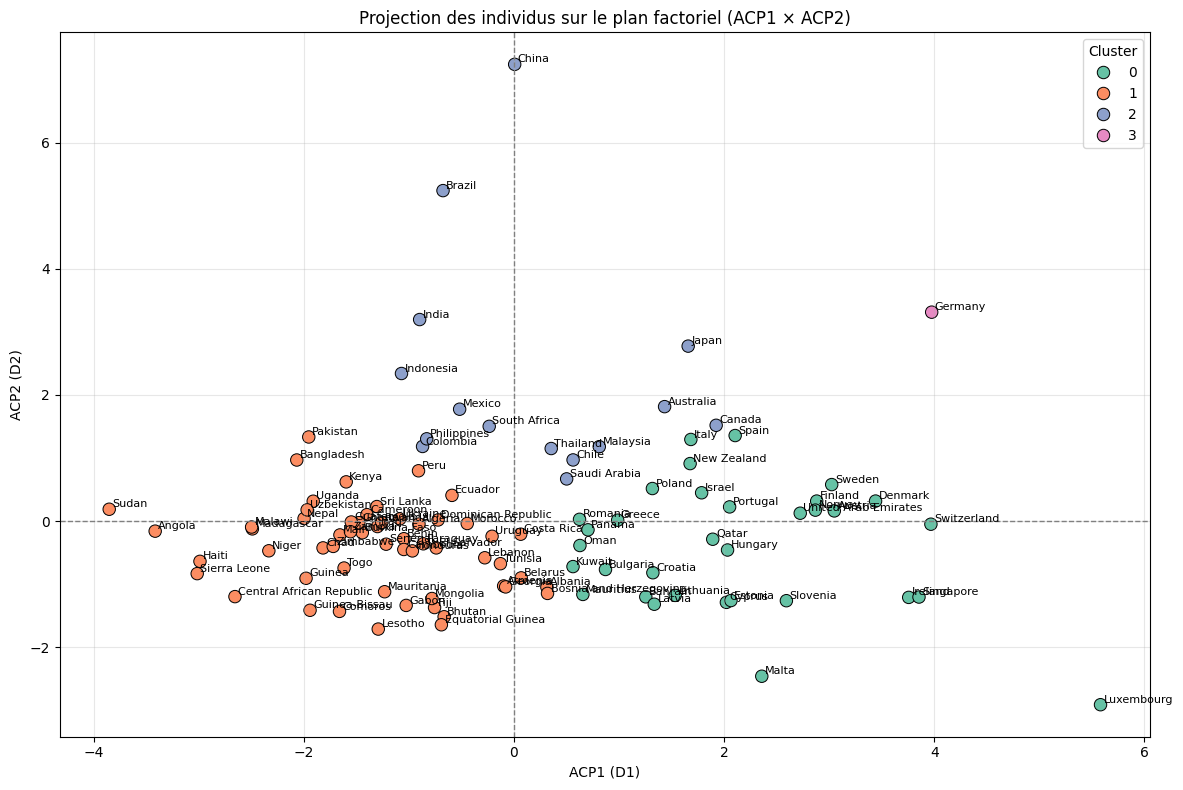

In [15]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=acp_df,
    x="D1",
    y="D2",
    hue="Cluster",
    palette="Set2",
    s=80,
    edgecolor="black"
)

# Nom des pays
for _, row in acp_df.iterrows():
    plt.text(
        row["D1"] + 0.03,
        row["D2"] + 0.03,
        row["Zone"],  
        fontsize=8
    )

plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.axvline(0, color="grey", linestyle="--", linewidth=1)

plt.xlabel("ACP1 (D1)")
plt.ylabel("ACP2 (D2)")
plt.title("Projection des individus sur le plan factoriel (ACP1 × ACP2)")

plt.legend(title="Cluster")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 12):  # au moins 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_acp)

    score = silhouette_score(X_acp, labels)
    scores.append(score)

    print(f"k = {k} : silhouette = {score:.3f}")

k = 2 : silhouette = 0.357
k = 3 : silhouette = 0.228
k = 4 : silhouette = 0.268
k = 5 : silhouette = 0.287
k = 6 : silhouette = 0.279
k = 7 : silhouette = 0.290
k = 8 : silhouette = 0.282
k = 9 : silhouette = 0.234
k = 10 : silhouette = 0.237
k = 11 : silhouette = 0.254


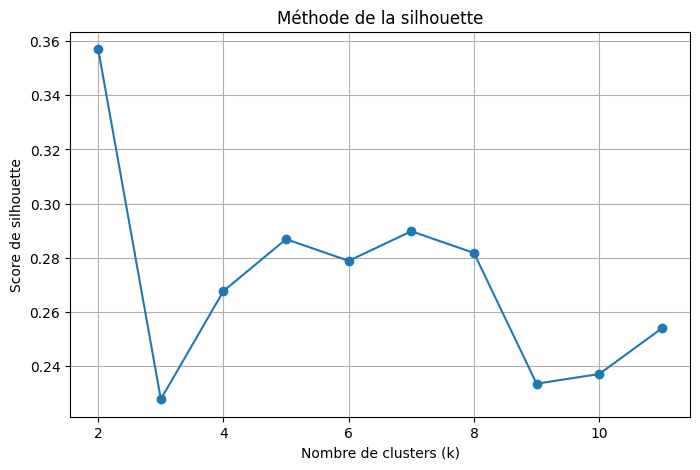

In [17]:
plt.figure(figsize=(8,5))
plt.plot(range(2,12), scores, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de silhouette")
plt.title("Méthode de la silhouette")
plt.grid(True)
plt.show()

In [18]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_acp)

# Ajouter les clusters uniquement aux lignes utilisées pour l’ACP
df_final.loc[X.index, "Cluster"] = clusters

In [19]:
df_final.groupby("Cluster")[[
    "Population",
    "disponibilite_volaille",
    "PIB_habitant",
    "Stabilité_Politique",
    "inflation",
    "index_ouverture",
    "index_log",
    "Balance_commerciale",
    "distance_france_km"
]].mean().round(2)

,Population,disponibilite_volaille,PIB_habitant,Stabilité_Politique,inflation,index_ouverture,index_log,Balance_commerciale,distance_france_km
Cluster,,,,,,,,,
0.0,9.474320e+06,265583.89,36100.65,1.06,1.61,126.17,3.23,-4736.36,3297.08
1.0,2.213485e+07,170392.35,3368.41,-0.51,5.37,65.64,2.26,-4437.60,6032.55
2.0,2.615206e+08,3827120.54,16250.70,0.57,2.70,59.05,3.16,2732.40,9469.18
3.0,8.310401e+07,1514081.00,45553.93,1.89,1.51,77.45,4.16,460563.00,881.02


In [20]:
df_final[df_final["Cluster"] == 0]

,Zone,ISO3,Population,disponibilite_volaille,PIB_habitant,Stabilité_Politique,inflation,index_ouverture,index_log,Balance_commerciale,distance_france_km,Population_log,PIB_habitant_log,Stabilité_Politique_log,inflation_log,distance_france_log,index_ouverture_log,disponibilite_volaille_log,Cluster
15,Austria,AUT,8798779,143750.00,47163.742578,1.613834,2.081269,105.556067,3.884790,-19628.0,1035.911497,15.990124,10.761402,0.960818,1.125342,6.944002,4.668671,11.875838,0.0
18,Bahrain,BHR,1482003,8928.00,24784.769351,0.422756,1.386718,136.429240,2.746803,-282.0,4843.109908,14.208906,10.118025,0.352596,0.869919,8.485519,4.923109,9.097060,0.0
34,Bulgaria,BGR,7075642,106954.83,8696.689304,-0.049436,2.061596,129.634434,2.841196,7391.0,1761.544642,15.772169,9.070813,-0.050700,1.118936,7.474514,4.872403,11.580171,0.0
52,Croatia,HRV,4079198,65414.82,13901.787814,0.404068,1.129372,97.245234,2.840257,2232.0,1081.986677,15.221411,9.539845,0.339374,0.755827,6.987478,4.587467,11.088519,0.0
55,Cyprus,CYP,1254274,25527.93,26247.449219,1.114617,0.531766,148.013356,2.847448,-311.0,2954.902800,14.042068,10.175362,0.748874,0.426422,7.991559,5.004036,10.147568,0.0
58,Denmark,DNK,5765164,151810.77,57521.551499,1.825419,1.147132,104.215677,3.824300,73601.0,1028.551510,15.567344,10.959932,1.038657,0.764133,6.936879,4.656012,11.930397,0.0
68,Estonia,EST,1317430,20400.00,20851.522350,1.068236,3.417235,144.635651,3.064361,-1498.0,1861.683830,14.091194,9.945230,0.726696,1.485514,7.529774,4.981108,9.923339,0.0
76,Finland,FIN,5508398,128809.00,46085.017474,2.110108,0.754015,75.938782,3.683032,-1159.0,1913.794237,15.521785,10.738265,1.134658,0.561907,7.557365,4.343010,11.766094,0.0
85,Greece,GRC,10753532,245896.00,18631.993013,0.262332,1.121255,70.882497,3.043642,-2738.0,2098.214106,16.190745,9.832689,0.232961,0.752008,7.649318,4.275033,12.412668,0.0
98,Hungary,HUN,9785608,493098.00,14736.166816,0.607657,2.348243,165.032856,3.249404,22426.0,1248.340497,16.096423,9.598128,0.474778,1.208436,7.130371,5.112186,13.108465,0.0


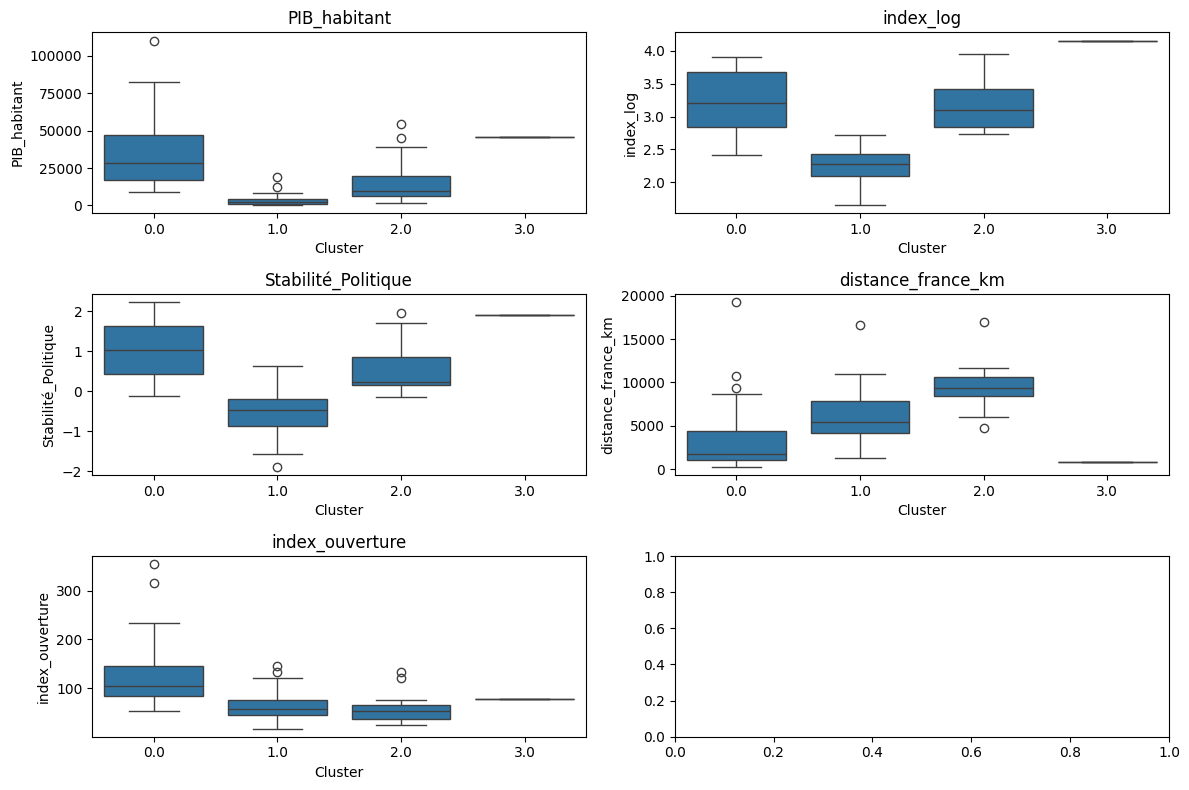

In [21]:
variables = [
    "PIB_habitant",
    "index_log",
    "Stabilité_Politique",
    "distance_france_km",
    "index_ouverture"
]

fig, axes = plt.subplots(3, 2, figsize=(12,8))

for ax, var in zip(axes.ravel(), variables):
    sns.boxplot(data=df_final, x="Cluster", y=var, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

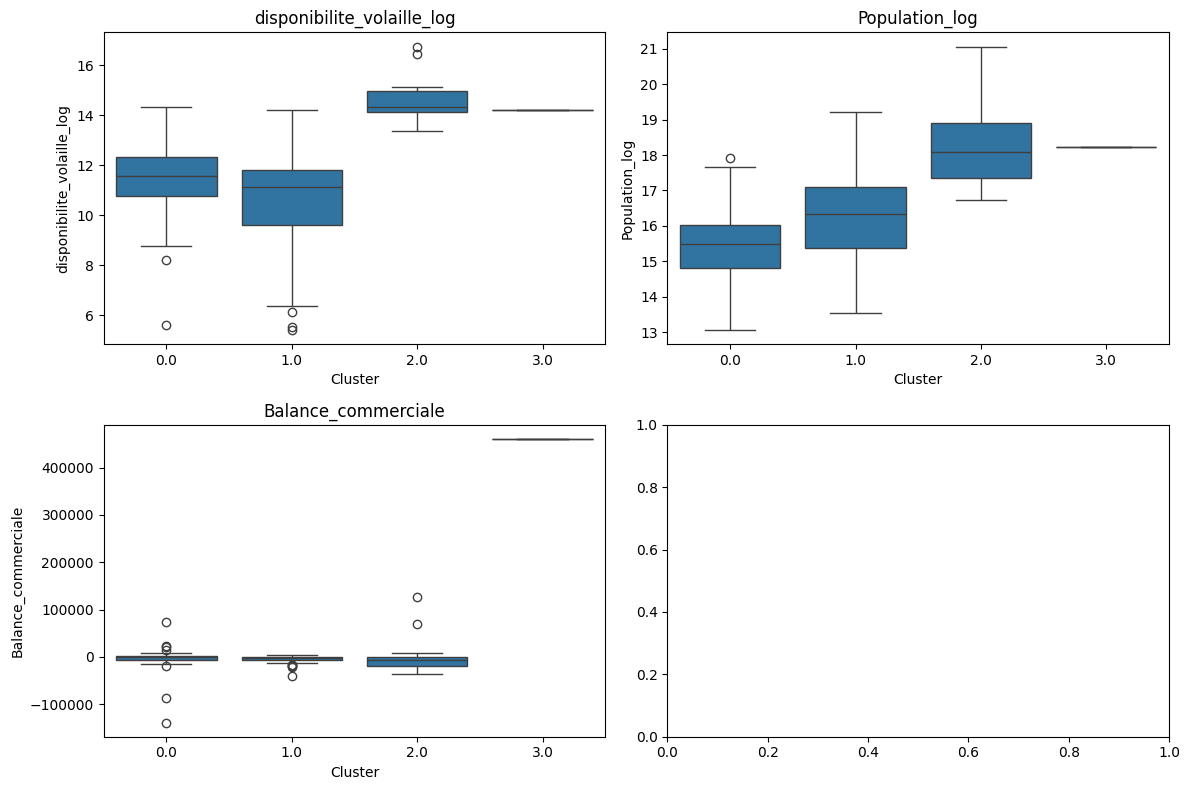

In [22]:
variables_2 = [
    "disponibilite_volaille_log",
    "Population_log",
    "Balance_commerciale"
]

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for ax, var in zip(axes.ravel(), variables_2):
    sns.boxplot(data=df_final, x="Cluster", y=var, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

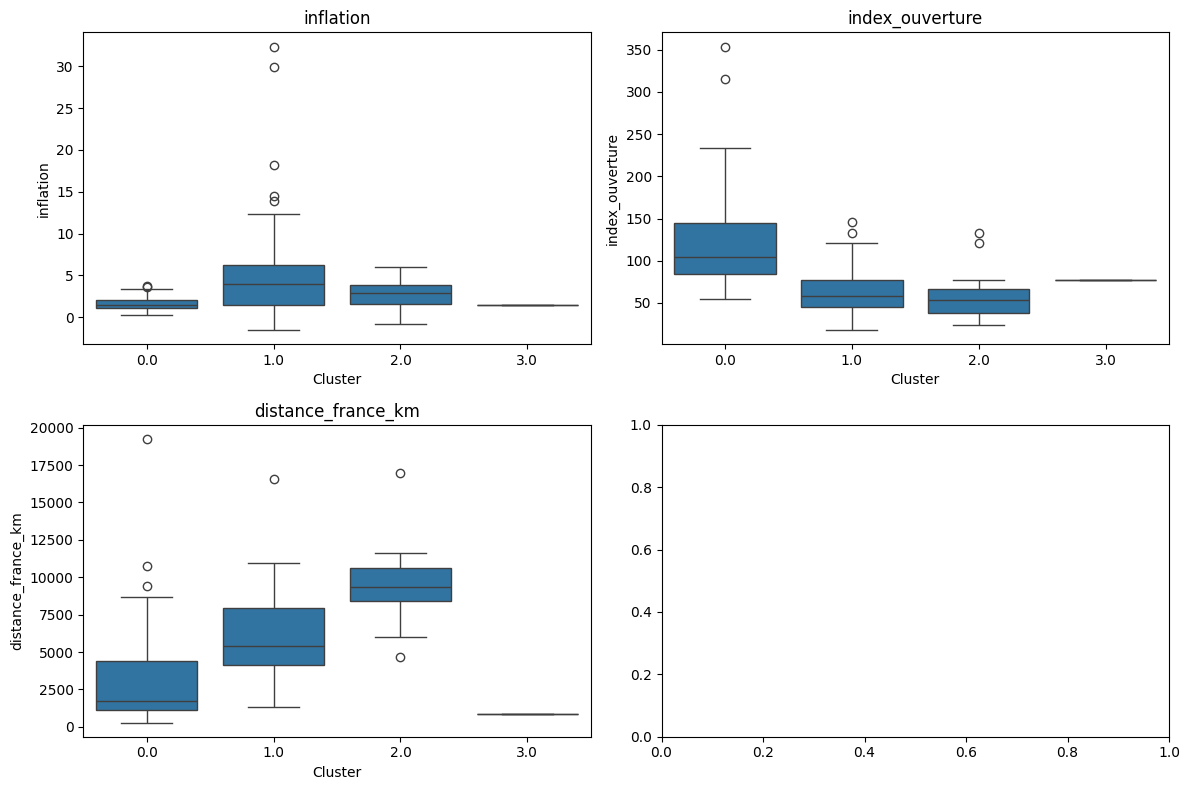

In [23]:
variables_3 = [
    "inflation",
    "index_ouverture",
    "distance_france_km"
]

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for ax, var in zip(axes.ravel(), variables_3):
    sns.boxplot(data=df_final, x="Cluster", y=var, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

(106, 6)
        Zone        D1        D2        D3        D4  Cluster
0    Albania  0.314237 -1.048553  0.341210 -0.186635      1.0
1    Algeria -0.903399 -0.046863  0.457787  0.683837      1.0
2     Angola -3.413639 -0.159264  1.344853  3.851048      1.0
3    Armenia -0.097527 -1.028647 -0.050342 -0.627813      1.0
4  Australia  1.433969  1.814708 -0.712138 -0.513244      2.0


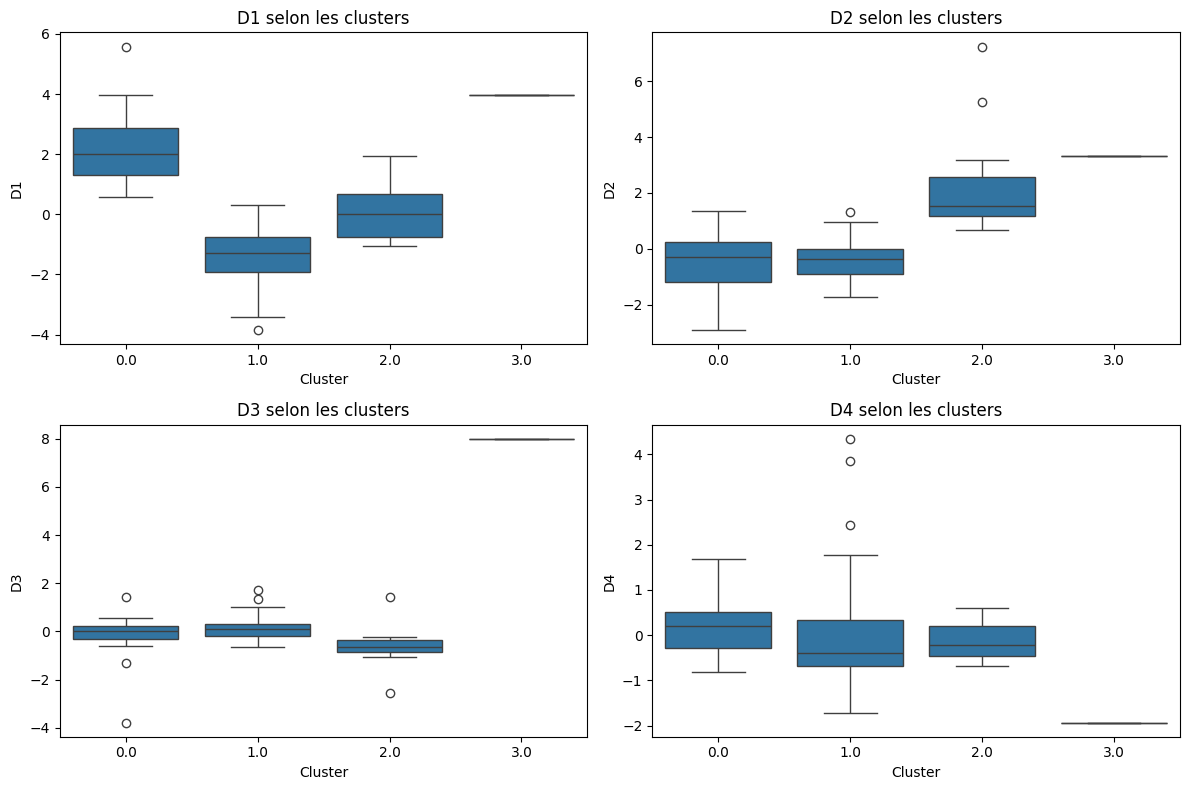

In [24]:
acp_scores = pd.DataFrame(
    X_acp,
    columns=["D1", "D2", "D3", "D4"]
)

acp_scores["Zone"] = df_final.loc[
    X.index,
    "Zone"
].values

acp_scores["Cluster"] = df_final.loc[
    X.index,
    "Cluster"
].values

acp_scores = acp_scores[
    ["Zone", "D1", "D2", "D3", "D4", "Cluster"]
]

print(acp_scores.shape)
print(acp_scores.head())


variables_acp = ["D1", "D2", "D3", "D4"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, var in zip(axes.ravel(), variables_acp):
    sns.boxplot(
        data=acp_scores,
        x="Cluster",
        y=var,
        ax=ax
    )
    ax.set_title(f"{var} selon les clusters")

plt.tight_layout()
plt.show()

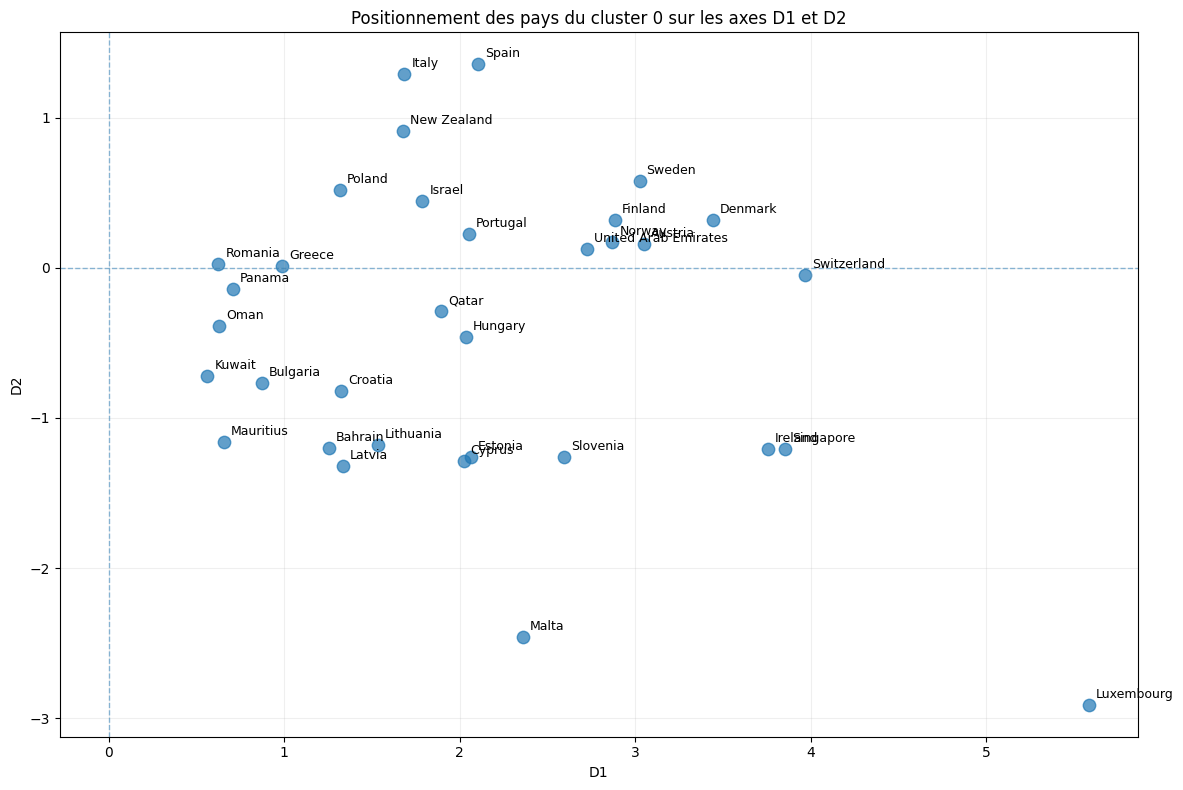

In [25]:
# Choisir le cluster
cluster = 0

# Données du cluster
df_cluster = acp_scores[
    acp_scores["Cluster"] == cluster
].copy()

plt.figure(figsize=(12, 8))

# Nuage de points
plt.scatter(
    df_cluster["D1"],
    df_cluster["D2"],
    s=80,
    alpha=0.7
)

# Ajouter le nom des pays
for _, row in df_cluster.iterrows():
    plt.annotate(
        row["Zone"],
        (row["D1"], row["D2"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

# Lignes de référence
plt.axhline(0, linewidth=1, linestyle="--", alpha=0.5)
plt.axvline(0, linewidth=1, linestyle="--", alpha=0.5)

plt.xlabel("D1")
plt.ylabel("D2")

plt.title(
    f"Positionnement des pays du cluster {cluster} sur les axes D1 et D2"
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

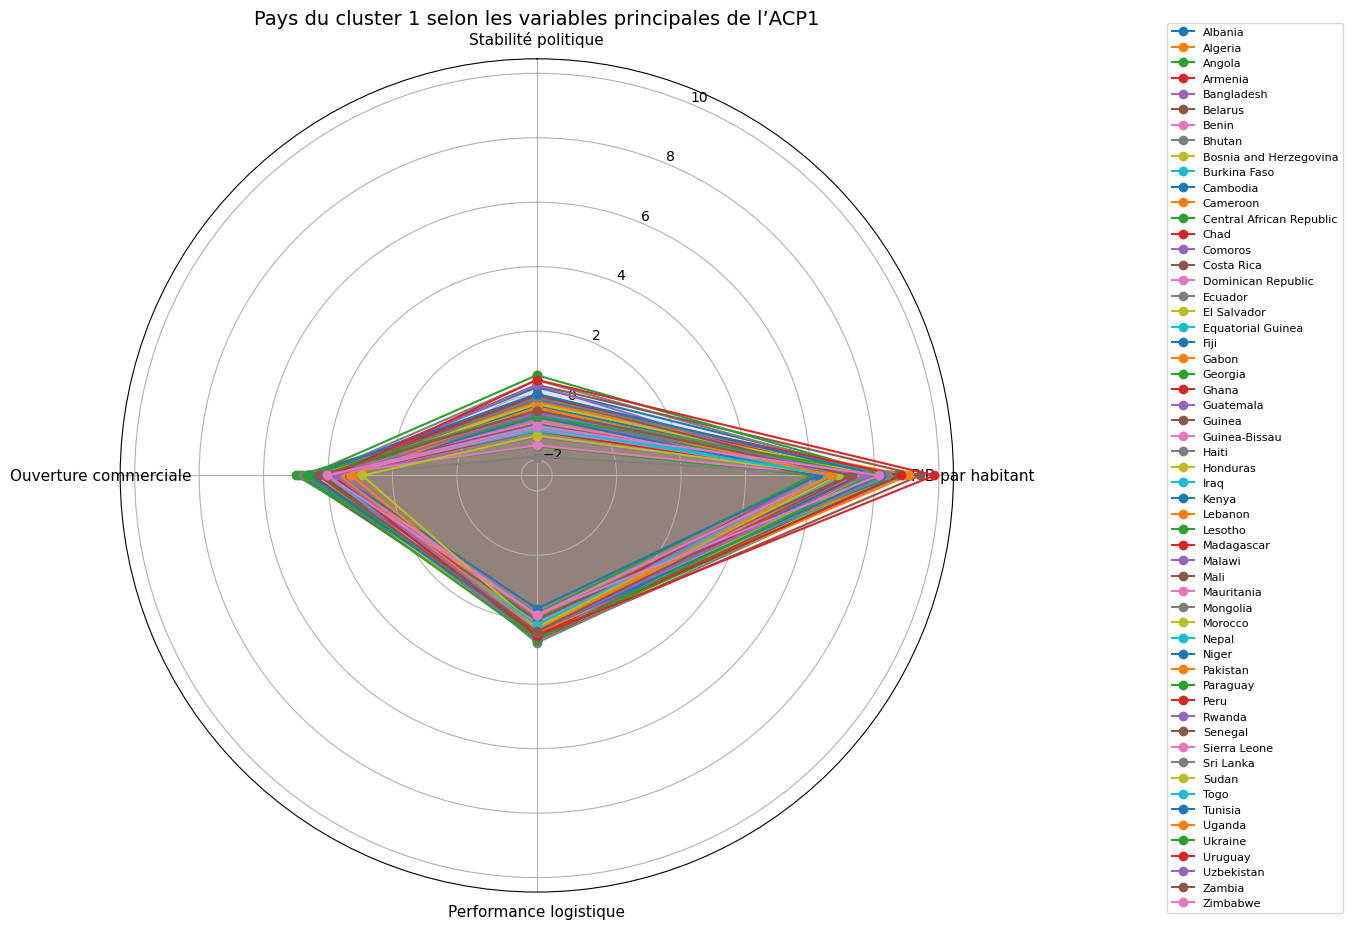

In [26]:
variables = [
    "Stabilité_Politique",
    "PIB_habitant_log",
    "index_log",
    "index_ouverture_log"
]

cluster1 = df_final[df_final["Cluster"] == 1].copy()

angles = np.linspace(
    0,
    2 * np.pi,
    len(variables),
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(12, 10),
    subplot_kw={"polar": True}
)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for _, row in cluster1.iterrows():

    valeurs = row[variables].astype(float).tolist()
    valeurs += valeurs[:1]

    ax.plot(
        angles,
        valeurs,
        linewidth=1.5,
        marker="o",
        label=row["Zone"]
    )

    ax.fill(
        angles,
        valeurs,
        alpha=0.03
    )

ax.set_xticks(angles[:-1])

ax.set_xticklabels(
    [
        "Stabilité politique",
        "PIB par habitant",
        "Performance logistique",
        "Ouverture commerciale"
    ],
    fontsize=11
)

ax.set_title(
    "Pays du cluster 1 selon les variables principales de l’ACP1",
    fontsize=14,
    pad=25
)

ax.legend(
    bbox_to_anchor=(1.25, 1.05),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21180\1873075850.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(variables, fontsize=11)


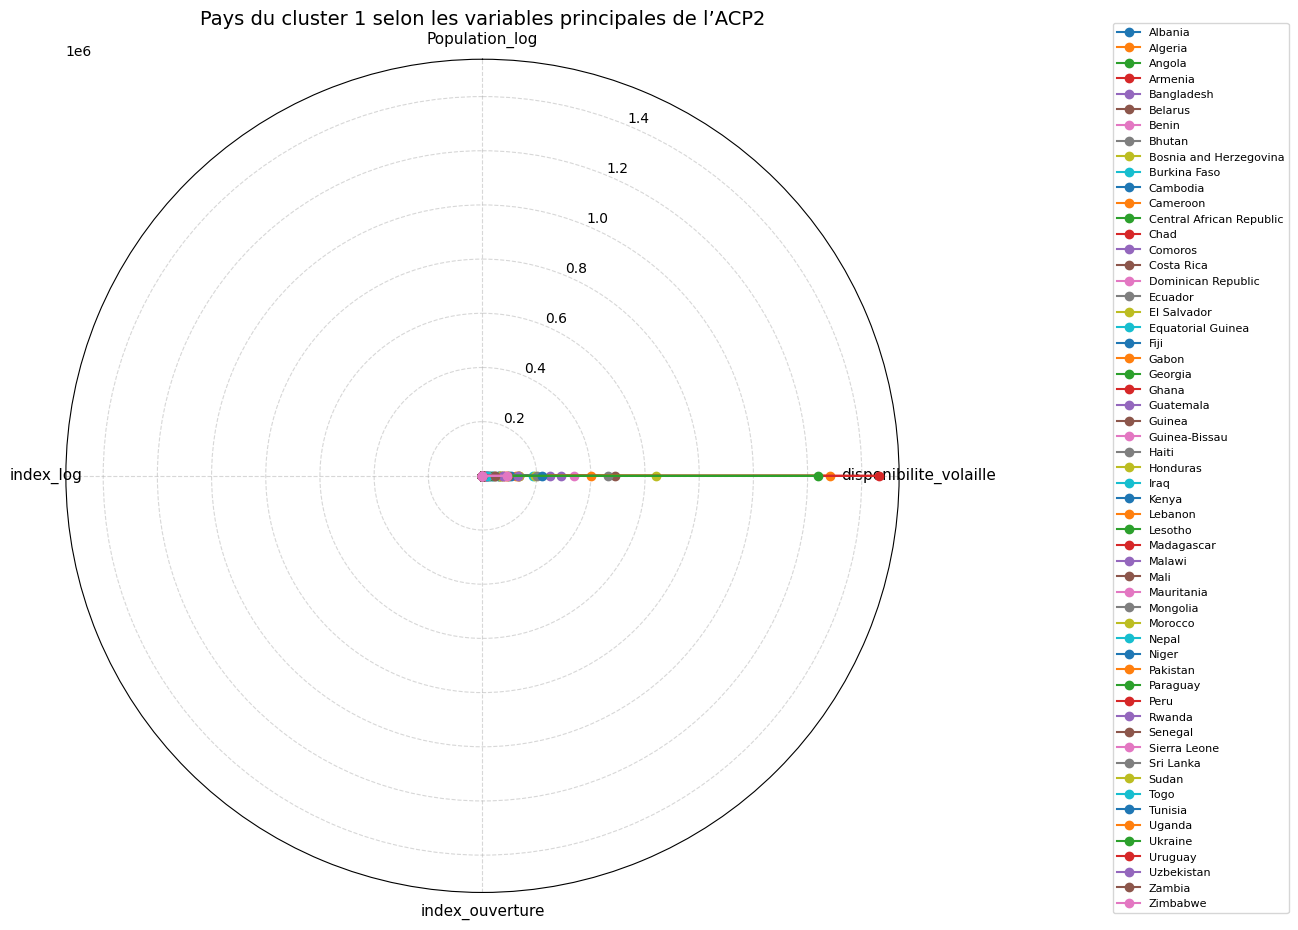

In [27]:
loadings_d2 = pd.Series(
    acp.components_[1],
    index=X.columns
)

variables = (
    loadings_d2
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

cluster1 = df_final[df_final["Cluster"] == 1].copy()

angles = np.linspace(
    0,
    2 * np.pi,
    len(variables),
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(12, 10),
    subplot_kw={"polar": True}
)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for _, row in cluster1.iterrows():

    valeurs = row[variables].astype(float).tolist()
    valeurs += valeurs[:1]

    ax.plot(
        angles,
        valeurs,
        linewidth=1.5,
        marker="o",
        label=row["Zone"]
    )


ax.set_xticklabels(variables, fontsize=11)
ax.set_xticks(angles[:-1])


ax.set_title(
    "Pays du cluster 1 selon les variables principales de l’ACP2",
    fontsize=14,
    pad=25
)

ax.legend(
    bbox_to_anchor=(1.25, 1.05),
    loc="upper left",
    fontsize=8
)

ax.grid(
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

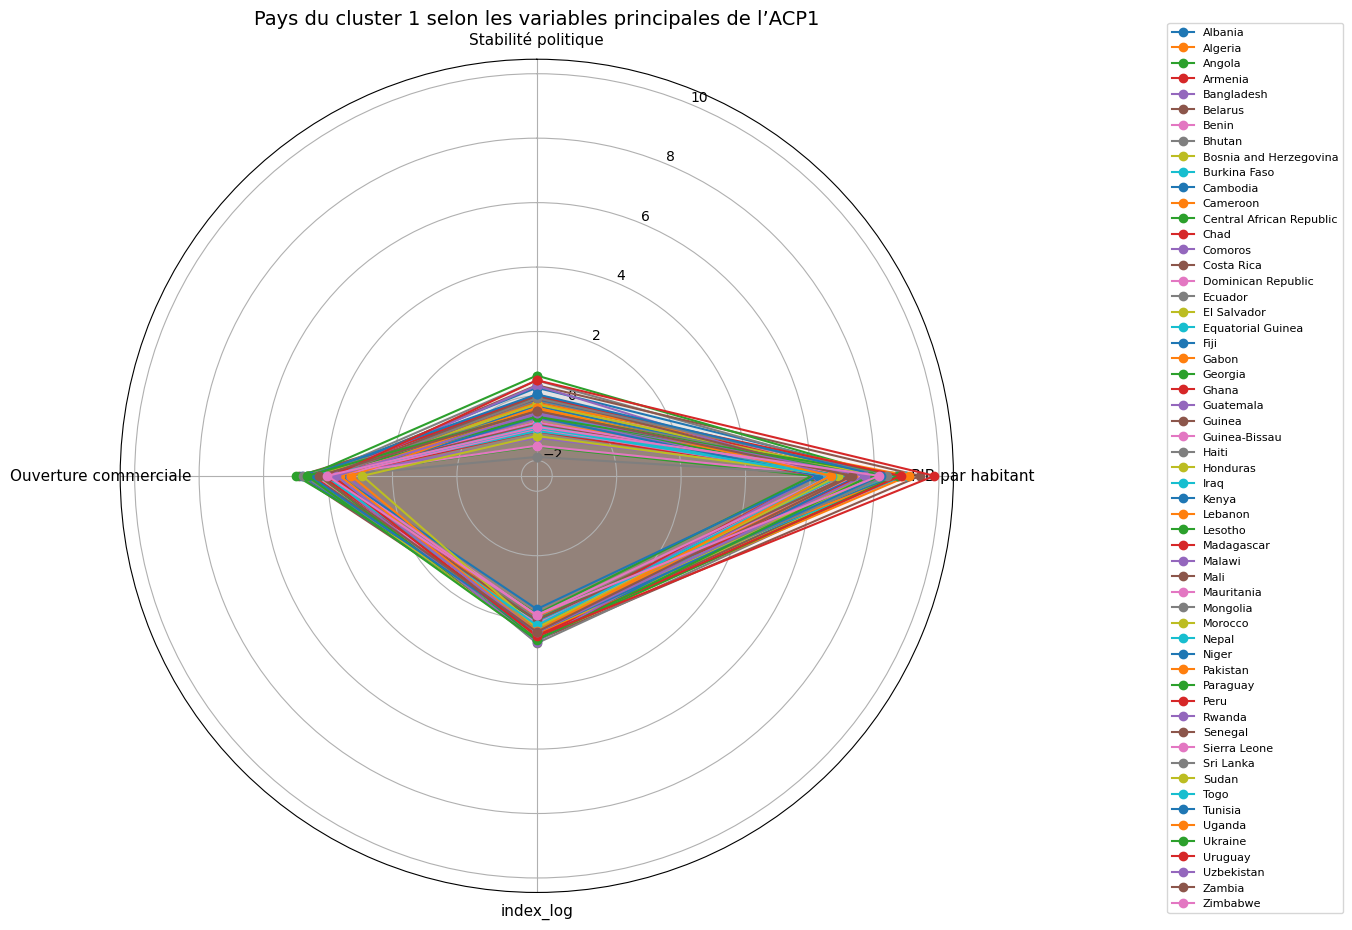

In [28]:
variables = [
    "Stabilité_Politique",
    "PIB_habitant_log",
    "index_log",
    "index_ouverture_log"
]

cluster1 = df_final[df_final["Cluster"] == 1].copy()

angles = np.linspace(
    0,
    2 * np.pi,
    len(variables),
    endpoint=False
).tolist()

angles += angles[:1]

fig, ax = plt.subplots(
    figsize=(12, 10),
    subplot_kw={"polar": True}
)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for _, row in cluster1.iterrows():

    valeurs = row[variables].astype(float).tolist()
    valeurs += valeurs[:1]

    ax.plot(
        angles,
        valeurs,
        linewidth=1.5,
        marker="o",
        label=row["Zone"]
    )

    ax.fill(
        angles,
        valeurs,
        alpha=0.03
    )

ax.set_xticks(angles[:-1])

ax.set_xticklabels(
    [
        "Stabilité politique",
        "PIB par habitant",
        "index_log",
        "Ouverture commerciale"
    ],
    fontsize=11
)

ax.set_title(
    "Pays du cluster 1 selon les variables principales de l’ACP1",
    fontsize=14,
    pad=25
)

ax.legend(
    bbox_to_anchor=(1.25, 1.05),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

In [29]:
pays_candidats = df_final[
    df_final["Cluster"].isin([0, 2, 3])
].copy()


criteres = [
    "Population_log",
    "PIB_habitant_log",
    "Stabilité_Politique",
    "index_ouverture",
    "index_log",
    "Balance_commerciale",
    "distance_france_log"
]


from sklearn.preprocessing import StandardScaler

scaler_score = StandardScaler()

pays_candidats[[c + "_std" for c in criteres]] = scaler_score.fit_transform(
    pays_candidats[criteres]
)

pays_candidats["Score"] = (
      pays_candidats["Population_log_std"]
    + pays_candidats["PIB_habitant_log_std"]
    + pays_candidats["Stabilité_Politique_std"]
    + pays_candidats["index_ouverture_std"]
    + pays_candidats["index_log_std"]
    - pays_candidats["distance_france_log_std"]
)


classement = pays_candidats.sort_values(
    "Score",
    ascending=False
)

classement[[
    "Zone",
    "Cluster",
    "Score"
]].head(10)

,Zone,Cluster,Score
127,Luxembourg,0.0,8.118787
213,Switzerland,0.0,6.373548
82,Germany,3.0,6.143167
198,Singapore,0.0,5.942271
104,Ireland,0.0,4.860002
58,Denmark,0.0,4.332117
15,Austria,0.0,4.204644
212,Sweden,0.0,4.139035
164,Norway,0.0,3.251716
230,United Arab Emirates,0.0,3.104122


In [ ]:
cluster1 = cluster1.sort_values("distance_france_km")

plt.figure(figsize=(12,5))
sns.barplot(data=cluster1, x="Zone", y="distance_france_km", color="red")
plt.xticks(rotation=90)
plt.title("Distance à la France des pays du cluster 1")
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Area` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x500 with 0 Axes>